In [1]:
import sys
import os

# Add the parent directory (project root) to the python path
sys.path.append(os.path.abspath(os.path.join('..')))


### Load model

In [2]:
import argparse
import os
import time
import traceback
import json
from typing import Any, Sequence


import numpy as np
import torch
from torch import Tensor
import yaml
from tqdm import tqdm
from PIL import ImageFilter
import pandas as pd
import scipy.stats as stats

# --- ABSTRACTED FACTORIES & UTILS ---
from src.datasets.factory import get_dataloader 
from src.explainers.utils import find_ynvqa_token_index, save_to_jsonl
from src.models.factory import load_vlm

# --- EXPLAINERS & METRICS ---
from src.metrics.shap_sii import eval_sii_auc_with_class
from src.metrics import FaithfulnessMetric
from src.metrics.faithfulness_utils import (
    _reshape_pixels_back_faithfulness,
    _reshape_pixels_faithfulness,
    get_most_important_tokens_multimodal,
    make_blur_baseline,
    score_output,
    get_text_mask,
)

In [146]:

def load_yaml(file_path):
    with open(file_path, encoding="utf-8") as f:
        return yaml.safe_load(f)

model_name = "qwenvl"
dataset_name = "repope_oracle"
gpu_id = 0


model_config = f"../configs/models/{model_name}.yaml"
model_config = load_yaml(model_config)

if dataset_name in ['repope', 'repope_oracle']:
    dataset_config = {
    "name": dataset_name,
    "data_path": "../datasets/repope",
    "pope_json_path": "../datasets/repope/repope_annotations",
    "pope_type": "all",
    "coco_split": "val2014",
    "batch_size": 1,
    }

else:

    dataset_config = f"../configs/datasets/{dataset_name}.yaml"
    dataset_config = load_yaml(dataset_config)



In [4]:
model_wrapper = load_vlm(
    model_config=model_config,
    attn_implementation="eager", 
    gpu_node=gpu_id,
    output_attentions=True
)


[*] Loading model architecture: Qwen/Qwen2.5-VL-3B-Instruct on GPU 0...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [147]:
dl = get_dataloader(dataset_config)

[*] Loading Dataset: repope_oracle
loading annotations into memory...
Done (t=2.54s)
creating index...
index created!
[*] Scanning 3 POPE json files...
[*] Built 'all' split. Total unique questions: 1203


In [219]:
target_category = "logical reasoning"  # Change this to whatever category you want to test!
match_count = 0
max_matches = 50

# Loop through the entire dataset's length
# for idx in range(len(dl.dataset)): 
idx = 36
sample = dl.dataset[idx]
category = sample.get("category", None)

# Check if it matches our target
#if category == target_category:
    
img = sample.get("image", None)
# constraint = "\nAnswer directly with only the letter inside parentheses, and nothing else. \nAnswer:"
constraint = "\nAnswer:"
question = sample.get("question", None)
if dataset_name in ["repope", "repope_oracle"]:
    text = question
else:
    text = question + constraint
label = sample.get("label", None)

keyword=sample.get("object_name", None)
oracle_mask_2d=sample.get("pixel_oracle_mask", None)
mismatched_mask_2d=sample.get("distractor_mask", None)

# inputs = model_wrapper.get_inputs(img, text)
# pred_results = model_wrapper.predict(inputs, return_logits=False, max_new_tokens=32)

# full_text = pred_results["text"]

# # I uncommented this safety check for you, it's good practice to keep it!
# if isinstance(full_text, list):
#     full_text = full_text[0]
    
# # Pass flattened IDs to the function
# decision_idx, decision_token_str = find_mcvqa_token_index(
#     pred_results["new_ids"], 
#     model_wrapper.processor.tokenizer,
#     choices=['a', 'b', 'c', 'd', 'e', 'f']
# )

# # Clean UI formatting
# print("-" * 60)
# # Added a tracker so you know which match number you are on (e.g., 1/50)
# print(f"Sample {idx} | Category: {category} | Match: {match_count + 1}/{max_matches}")
# print(f"Question     : {question}")
# print(f"Model Answer : {full_text.strip()}")
# print(f"True Label   : {label}")

# if decision_idx != -1:
#     print(f"FOUND TOKEN  : '{decision_token_str}' (Index: {decision_idx})")
# else:
#     print(f"FOUND TOKEN  : [FAILED TO PARSE]")
# print("-" * 60)

# # Increment our counter
# match_count += 1

# # Stop the loop if we've found 50 matches
# if match_count >= max_matches:
#     print(f"[*] Successfully found and processed {max_matches} '{target_category}' samples. Stopping.")
#     break




In [220]:
for var in ['inputs', 'pred_results', 'xai_result', 'img_attrs', 'text_attrs']:
    if var in locals():
        del locals()[var]

In [221]:
import gc

gc.collect()
                        
torch.cuda.empty_cache()

In [222]:
sample

{'image': <PIL.Image.Image image mode=RGB size=500x342>,
 'question': 'Is there a frisbee in the image?',
 'object_name': 'frisbee',
 'pixel_oracle_mask': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 'distractor_mask': tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8),
 'distractor_category': 'car',
 'image_id': 219622}

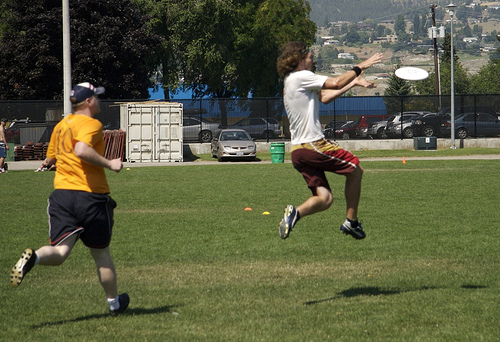

In [264]:
img

In [265]:
inputs = model_wrapper.get_inputs(img, text)
pred_results = model_wrapper.predict(inputs, return_logits=True)

In [266]:
print(pred_results["text"])

Yes, there is a frisbee in the image.


In [267]:
from src.explainers.utils import find_mcvqa_token_index, find_ynvqa_token_index

if dataset_name in ["repope", "repope_all"]:
    decision_token = find_ynvqa_token_index(
                        pred_results["new_ids"],
                        text_answer=pred_results["text"],
                        tokenizer=model_wrapper.processor.tokenizer,
                    )
else:
    decision_token, _ = find_mcvqa_token_index(pred_results["new_ids"], model_wrapper.processor.tokenizer,
                                            choices=['a', 'b', 'c', 'd', 'e', 'f'])

decision_token

4

In [268]:
model_wrapper.model_config = {
    "model_config": model_config,
    "attn_implementation": None,
    "gpu_node": gpu_id,
    "output_attentions": False
}

In [269]:
from src.explainers.factory import get_explainer

exp = "oracle"
explainer_path = f"../configs/explainers/{exp}.yaml"

explainer, explainer_name = get_explainer(
            explainer_path, model_wrapper, model_config
        )

In [270]:
target_indices = None
#target_indices = [decision_token]

text_attrs, img_attrs = explainer.attribute(
    img,
    text=text,
    target_indices=target_indices,
    pred_results=pred_results,
    keyword=keyword,
    oracle_mask_2d=oracle_mask_2d,
    mismatched_mask_2d=mismatched_mask_2d,

)

In [208]:
img_attrs.shape

torch.Size([12, 1380])

In [209]:
text_attrs.shape

torch.Size([12, 375])

#### Plausibility

In [ ]:
from src.models import QwenVLWrapper

model_wrapper = QwenVLWrapper(model, processor)


In [ ]:
from src.datasets import COCOGroundingDataset
from torch.utils.data import DataLoader

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)


In [ ]:
for sample in dl:
    img = sample["image"]
    text = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    break

In [ ]:
inputs = model_wrapper.get_inputs(img, text)
pred_results = model_wrapper.predict(inputs, return_logits=True)

In [ ]:
from src.explainers import (CaptumExplainer, LXTExplainer, TAMExplainer,
                            LLaVACAMExplainer, RandomExplainer,
                            )

target_layer_name = "layers.7.post_attention_layernorm"

# explainer = LLaVACAMExplainer(model_wrapper=model_wrapper,
#                             target_layer_name=target_layer_name
#                             )

explainer = TAMExplainer(model_wrapper=model_wrapper,
                           # use_zennit=True,
                           )


In [ ]:
from src.metrics import PlausibilityMetric
from src.metrics.plausibility_utils import OntologyMapper, ids_to_word_groups

# Setup Ontology Mapper for Plausibility (Assume dl.dataset has id2name)
category_dict = getattr(dl.dataset, "id2name", {})
mapper = OntologyMapper(coco_categories=category_dict, threshold=0.5)

plaus_metrics = PlausibilityMetric(
        ontology_mapper=mapper,
        category_dict=category_dict
    )

In [ ]:
tokens = pred_results["new_ids"].cpu().unsqueeze(0).tolist()
tokens

In [ ]:
words, tokens_id_groups = ids_to_word_groups(tokens, model_wrapper.processor)
words

In [ ]:
valid_words, target_indices = plaus_metrics.get_valid_targets(
                        words, tokens_id_groups, masks
                    )

In [ ]:
valid_words

In [ ]:
text_attrs, img_attrs = explainer.attribute(
                        img,
                        text=text,
                        target_indices=target_indices,
                        pred_results=pred_results,
                    )

In [ ]:
xai_result = {
        "inputs": inputs,
        "target_ids": pred_results["new_ids"].unsqueeze(0),
        "pixel_attribution": img_attrs, 
        "token_attribution": text_attrs,
        "valid_words": valid_words  # Crucial for Plausibility to map rows to words
    }



In [ ]:
from src.metrics import FaithfulnessMetric

# 5. Initialize Metrics
pert_steps = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
tok = model_wrapper.processor.tokenizer
pad_token_id = tok.pad_token_id if tok.pad_token_id is not None else 0

faith_metrics = FaithfulnessMetric(
    perturbation_steps=pert_steps,
    pad_token_id=pad_token_id,
    special_token_ids=model_wrapper.special_token_ids,
    mask_value=0.0,
    filter_keywords=True,
)

In [ ]:
faith_sample = {"image": img, "text": text}

# 6. Compute Both Metrics Using the Exact Same Data!
faith_scores = faith_metrics.compute(model_wrapper, faith_sample, xai_result)
plaus_scores = plaus_metrics.compute(model_wrapper, sample, xai_result)


In [ ]:
faith_scores

#### Faithfulness

In [271]:
# 4. Metric Hyperparameters
pert_steps = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
device = model_wrapper.device
tok = model_wrapper.processor.tokenizer
pad_token_id = tok.pad_token_id if tok.pad_token_id is not None else 0
special_token_ids = model_wrapper.special_token_ids
filter_keywords = True

faith_metrics = FaithfulnessMetric(
    perturbation_steps=pert_steps,
    pad_token_id=pad_token_id,
    special_token_ids=model_wrapper.special_token_ids,
    mask_value=0.0,
    filter_keywords=filter_keywords,
)

In [272]:
xai_result = {
    "inputs": inputs,
    "target_ids": pred_results["new_ids"].unsqueeze(0),
    "pixel_attribution": img_attrs[0:1],
    "token_attribution": text_attrs[0:1],
}

faith_sample ={"image": img, "text": sample["question"]}

scores = faith_metrics.compute(model_wrapper, faith_sample, xai_result, 
                               required_metrics=["auc", "curve"])

In [273]:
scores #  Random

{'time_img_pert': 2.7799513270001626,
 'img_raw_curve_del': [0.96875,
  0.9609375,
  0.9453125,
  0.94140625,
  0.9609375,
  0.96875,
  0.95703125,
  0.9296875,
  0.9296875,
  0.478515625,
  0.1357421875],
 'img_normalized_curve_del': [1.0,
  0.9906213283538818,
  0.9718639850616455,
  0.9671746492385864,
  0.9906213283538818,
  1.0,
  0.9859319925308228,
  0.953106701374054,
  0.953106701374054,
  0.4114888608455658,
  0.0],
 'img_raw_curve_ins': [0.1357421875,
  0.76953125,
  0.9453125,
  0.90625,
  0.9609375,
  0.95703125,
  0.9375,
  0.94140625,
  0.94140625,
  0.94140625,
  0.96875],
 'img_normalized_curve_ins': [0.0,
  0.7608440518379211,
  0.9718639850616455,
  0.9249706864356995,
  0.9906213283538818,
  0.9859319925308228,
  0.9624853730201721,
  0.9671746492385864,
  0.9671746492385864,
  0.9671746492385864,
  1.0],
 'img_norm_auc_del': 0.8723915562033653,
 'img_norm_auc_ins': 0.8998241335153578,
 'img_auc_del': 0.8624511718750002,
 'img_auc_ins': 0.8853027343750001,
 'time_to

#### Visualization

In [230]:
from src.explainers.utils import XAIVisualizer
from src.metrics.faithfulness_utils import get_text_mask

viz = XAIVisualizer(model_wrapper.processor)

In [231]:
token_attribution = text_attrs[0:1]
pixel_attribution = img_attrs[0:1]
target_ids = pred_results["new_ids"]

img_attrs = img_attrs.float()
text_attrs = text_attrs.float()

model_type = getattr(model_wrapper.model.config, "model_type", "").lower()
semantic_mask = get_text_mask(inputs["input_ids"],
                            model_type,
                            model_wrapper.processor.tokenizer)

In [232]:
viz.plot_text_attributions(
    text_attr=text_attrs, 
    input_ids=inputs["input_ids"], 
    target_ids=target_ids.unsqueeze(0),
    special_token_ids=model_wrapper.special_token_ids,
    semantic_mask=semantic_mask,
    target_indices=target_indices
)


TEXT ATTRIBUTIONS (Filtered & Normalized)


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
Yes,Yes (1.00),Yes,3.00,Is there a fr is bee in the image ?
",",", (1.00)",",",3.00,Is there a fr is bee in the image ?
there,there (1.00),there,3.00,Is there a fr is bee in the image ?
is,is (1.00),is,3.00,Is there a fr is bee in the image ?
a,a (1.00),a,3.00,Is there a fr is bee in the image ?
fr,fr (1.00),fr,3.00,Is there a fr is bee in the image ?
is,is (1.00),is,3.00,Is there a fr is bee in the image ?
bee,bee (1.00),bee,3.00,Is there a fr is bee in the image ?
in,in (1.00),in,3.00,Is there a fr is bee in the image ?
the,the (1.00),the,3.00,Is there a fr is bee in the image ?



IMAGE ATTRIBUTIONS

[*] Heatmap for generated token: 'Yes'


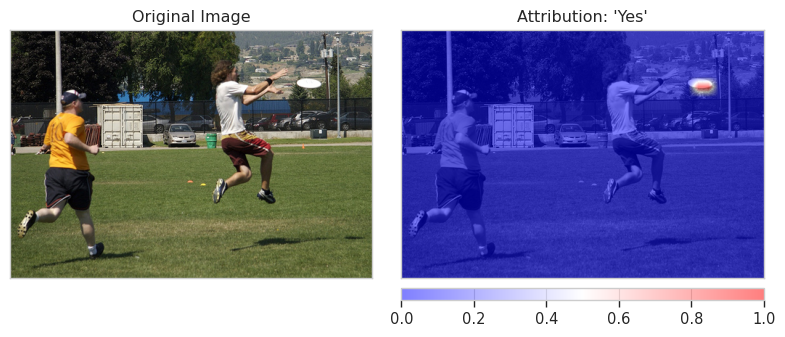

In [233]:
image_grid_thw = inputs.get("image_grid_thw", None)
viz.plot_image_attributions(img_attr=pixel_attribution,
                            original_image=img,
                            target_ids=target_ids.unsqueeze(0), 
                            image_grid_thw=image_grid_thw,
                            target_indices=target_indices
                            )